In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import os

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving 5G_QoS_Dataset.csv to 5G_QoS_Dataset.csv


In [ ]:
import pandas as pd

# Replace filename with your uploaded file name
df = pd.read_csv("5G_QoS_Dataset.csv")

df.head()


,Time_ms,UE_ID,Traffic_Type,PacketSize_Bytes,SINR_dB,RB_Allocation,Throughput_Mbps,Delay_ms,Action,Reward
0,2.185431,46,eMBB,1498,18.771788,79,148.297125,32.482120,79,4.565500
1,6.963645,31,mMTC,188,14.270042,9,12.843037,44.593359,9,0.288003
2,10.757618,50,mMTC,185,11.723268,16,18.757229,60.767392,16,0.308673
3,13.951581,29,mMTC,96,13.121796,15,19.682694,40.513809,15,0.485827
4,15.153665,48,mMTC,133,13.778473,15,20.667710,31.977875,15,0.646313


In [ ]:
# Sort by time
df = df.sort_values("Time_ms")


In [ ]:
import matplotlib.pyplot as plt

# Convert time
df["Time_s"] = df["Time_ms"] / 5

# Sort by time
df = df.sort_values("Time_s")


In [ ]:
embb = df[df["Traffic_Type"] == "eMBB"]
urllc = df[df["Traffic_Type"] == "URLLC"]
mmtc = df[df["Traffic_Type"] == "mMTC"]


In [ ]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "lines.linewidth": 1.8,
})


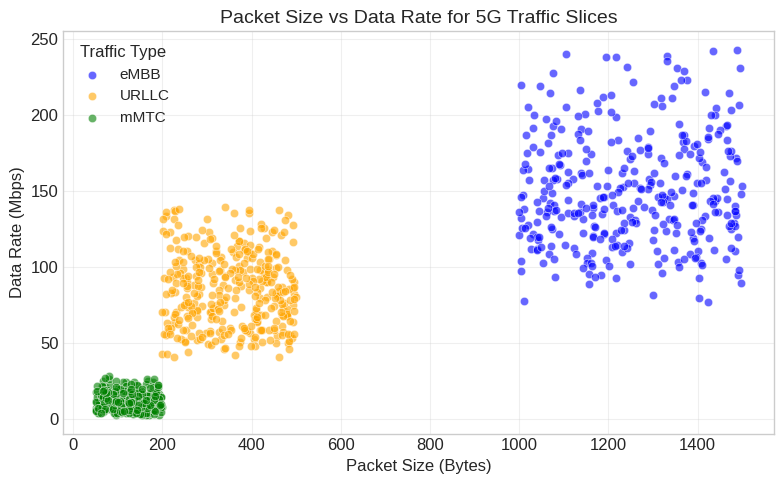

/tmp/ipykernel_1362/3080084968.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Traffic Type")


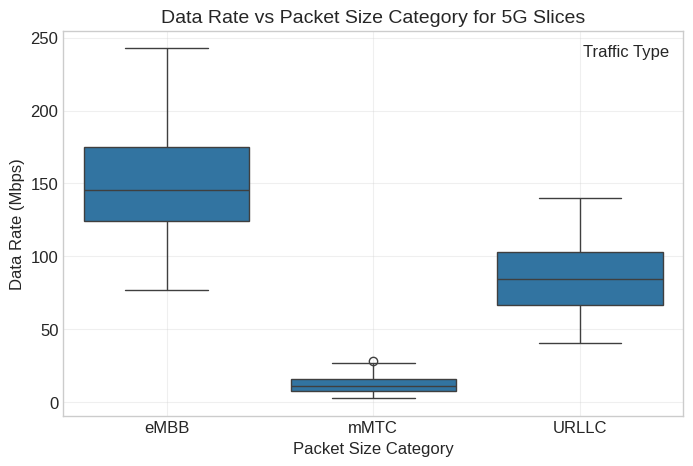

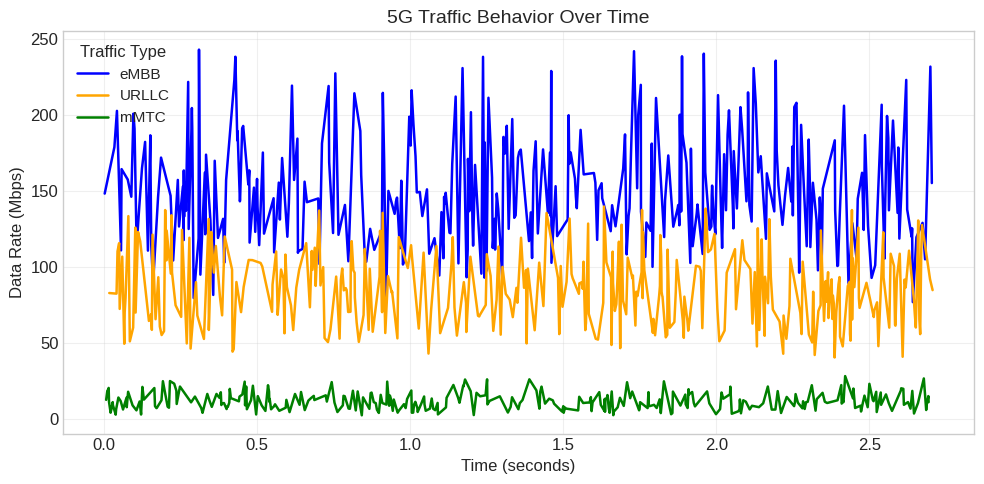

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# 1. TIME CONVERSION

df["Time_s"] = df["Time_ms"] / 1000

# sort by time
df = df.sort_values("Time_s")

# 2. DATA SLICES

embb = df[df["Traffic_Type"] == "eMBB"]
urllc = df[df["Traffic_Type"] == "URLLC"]
mmtc = df[df["Traffic_Type"] == "mMTC"]


# 🔹 PLOT 1: SCATTER (MAIN PLOT)

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=embb["PacketSize_Bytes"],
    y=embb["Throughput_Mbps"],
    color="blue",
    alpha=0.6,
    label="eMBB"
)

sns.scatterplot(
    x=urllc["PacketSize_Bytes"],
    y=urllc["Throughput_Mbps"],
    color="orange",
    alpha=0.6,
    label="URLLC"
)

sns.scatterplot(
    x=mmtc["PacketSize_Bytes"],
    y=mmtc["Throughput_Mbps"],
    color="green",
    alpha=0.6,
    label="mMTC"
)

plt.xlabel("Packet Size (Bytes)")
plt.ylabel("Data Rate (Mbps)")
plt.title("Packet Size vs Data Rate for 5G Traffic Slices")
plt.legend(title="Traffic Type")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


#  PLOT 2: BOX PLOT (REPORT)

df["PacketSize_Group"] = pd.cut(
    df["PacketSize_Bytes"],
    bins=[0,200,600,1600],
    labels=["Small","Medium","Large"]
)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Traffic_Type",
    y="Throughput_Mbps",
    data=df
)

plt.xlabel("Packet Size Category")
plt.ylabel("Data Rate (Mbps)")
plt.title("Data Rate vs Packet Size Category for 5G Slices")

plt.legend(title="Traffic Type")
plt.grid(alpha=0.3)

plt.show()


#  PLOT 3: TIME vs DATA RATE

plt.figure(figsize=(10,5))

plt.plot(embb["Time_s"], embb["Throughput_Mbps"], label="eMBB", color="blue")
plt.plot(urllc["Time_s"], urllc["Throughput_Mbps"], label="URLLC", color="orange")
plt.plot(mmtc["Time_s"], mmtc["Throughput_Mbps"], label="mMTC", color="green")

plt.xlabel("Time (seconds)")
plt.ylabel("Data Rate (Mbps)")
plt.title("5G Traffic Behavior Over Time")

plt.legend(title="Traffic Type")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1362/3465379639.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


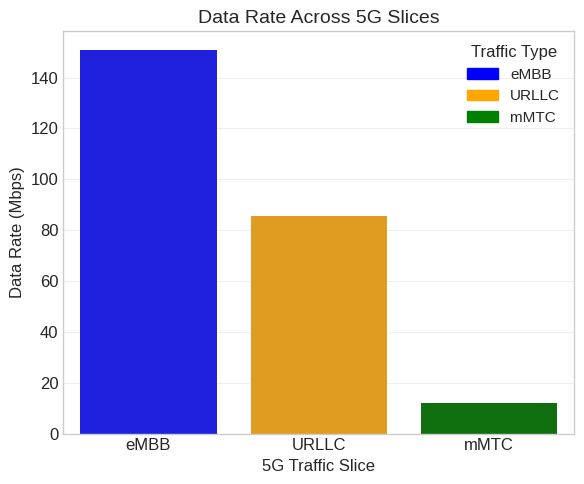

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# compute average data rate per slice
slice_avg = df.groupby("Traffic_Type")["Throughput_Mbps"].mean().reset_index()

plt.figure(figsize=(6,5))

# FIXED COLOR ORDER (important)
order = ["eMBB", "URLLC", "mMTC"]
colors = ["blue", "orange", "green"]

sns.barplot(
    x="Traffic_Type",
    y="Throughput_Mbps",
    data=slice_avg,
    order=order,
    palette=colors
)

# labels
plt.xlabel("5G Traffic Slice")
plt.ylabel("Data Rate (Mbps)")
plt.title("Data Rate Across 5G Slices")

#  CORRECT LEGEND (manually mapped to colors)
legend_handles = [
    mpatches.Patch(color="blue", label="eMBB"),
    mpatches.Patch(color="orange", label="URLLC"),
    mpatches.Patch(color="green", label="mMTC")
]

plt.legend(handles=legend_handles, title="Traffic Type", loc="upper right")

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

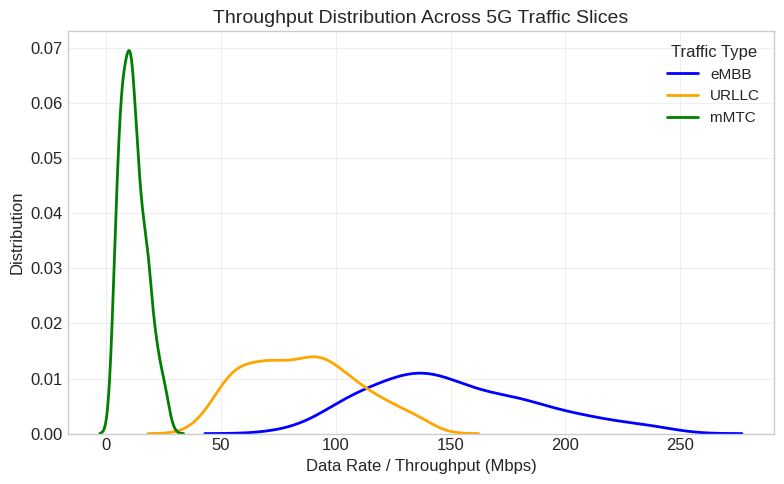

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# eMBB
sns.kdeplot(
    embb["Throughput_Mbps"],
    label="eMBB",
    color="blue",
    linewidth=2
)

# URLLC
sns.kdeplot(
    urllc["Throughput_Mbps"],
    label="URLLC",
    color="orange",
    linewidth=2
)

# mMTC
sns.kdeplot(
    mmtc["Throughput_Mbps"],
    label="mMTC",
    color="green",
    linewidth=2
)

# labels
plt.xlabel("Data Rate / Throughput (Mbps)")
plt.ylabel("Distribution")
plt.title("Throughput Distribution Across 5G Traffic Slices")

plt.legend(title="Traffic Type")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

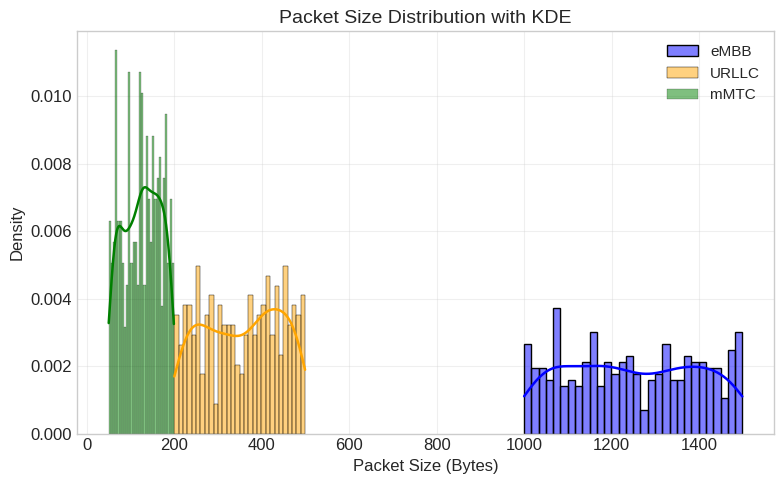

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# eMBB
sns.histplot(
    embb["PacketSize_Bytes"],
    bins=30,
    stat="density",
    kde=True,
    color="blue",
    alpha=0.5,
    edgecolor="black",
    label="eMBB"
)

# URLLC
sns.histplot(
    urllc["PacketSize_Bytes"],
    bins=30,
    stat="density",
    kde=True,
    color="orange",
    alpha=0.5,
    edgecolor="black",
    label="URLLC"
)

# mMTC
sns.histplot(
    mmtc["PacketSize_Bytes"],
    bins=30,
    stat="density",
    kde=True,
    color="green",
    alpha=0.5,
    edgecolor="black",
    label="mMTC"
)

plt.xlabel("Packet Size (Bytes)")
plt.ylabel("Density")
plt.title("Packet Size Distribution with KDE")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()




In [ ]:
# Combine for global normalization
all_rates = pd.concat([embb_rate, urllc_rate, mmtc_rate])

global_min = all_rates.min()
global_max = all_rates.max()

# Normalize
embb_norm = (embb_rate - global_min) / (global_max - global_min)
urllc_norm = (urllc_rate - global_min) / (global_max - global_min)
mmtc_norm = (mmtc_rate - global_min) / (global_max - global_min)

# Plot
plt.figure(figsize=(8,5))

plt.plot(embb_norm, marker='o', label="eMBB")   # circle markers
plt.plot(urllc_norm, marker='s', label="URLLC") # square markers
plt.plot(mmtc_norm, marker='^', label="mMTC")   # triangle markers

plt.xlabel("Time (s)")
plt.ylabel("Normalized Packet Arrival Rate (0–1)")
plt.title("Normalized Packet Arrival Rate Comparison")

plt.legend()
plt.tight_layout()
plt.savefig("arrival_rate_norm.png", dpi=300, bbox_inches="tight")

plt.show()

NameError: name 'embb_rate' is not defined

In [ ]:
plt.figure(figsize=(8,5))

plt.boxplot([
    embb["Delay_ms"],
    urllc["Delay_ms"],
    mmtc["Delay_ms"]
])

plt.xticks([1,2,3],["eMBB","URLLC","mMTC"])
plt.ylabel("Delay (ms)")
plt.title("Delay Variability Across Traffic Types")
plt.tight_layout()
plt.show()


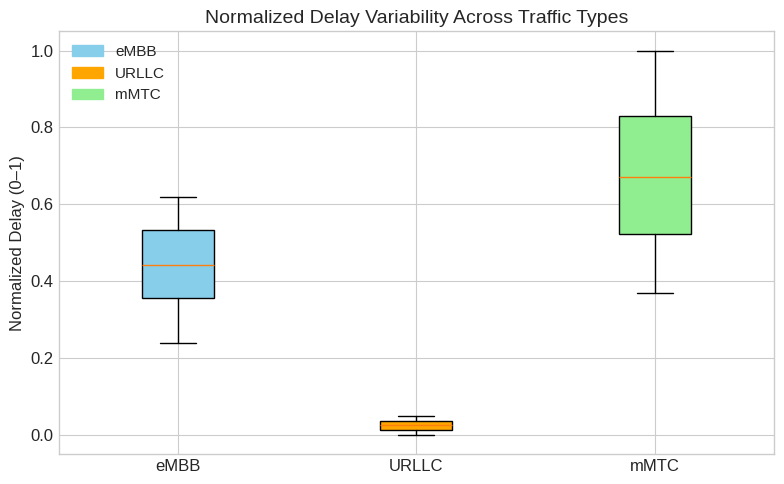

In [ ]:
import matplotlib.patches as mpatches

# Combine all delay values
all_delay = pd.concat([
    embb["Delay_ms"],
    urllc["Delay_ms"],
    mmtc["Delay_ms"]
])

global_min = all_delay.min()
global_max = all_delay.max()

# Normalize each
embb_delay_norm = (embb["Delay_ms"] - global_min) / (global_max - global_min)
urllc_delay_norm = (urllc["Delay_ms"] - global_min) / (global_max - global_min)
mmtc_delay_norm = (mmtc["Delay_ms"] - global_min) / (global_max - global_min)

# Plot
plt.figure(figsize=(8,5))

box = plt.boxplot([
    embb_delay_norm,
    urllc_delay_norm,
    mmtc_delay_norm
], patch_artist=True)

# Colors for boxes
colors = ['skyblue','orange','lightgreen']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.xticks([1,2,3],["eMBB","URLLC","mMTC"])
plt.ylabel("Normalized Delay (0–1)")
plt.title("Normalized Delay Variability Across Traffic Types")

# Create legend manually
legend_patches = [
    mpatches.Patch(color='skyblue', label='eMBB'),
    mpatches.Patch(color='orange', label='URLLC'),
    mpatches.Patch(color='lightgreen', label='mMTC')
]

plt.legend(handles=legend_patches, loc='upper left')

plt.tight_layout()
plt.savefig("delay_norm.png", dpi=300, bbox_inches="tight")

plt.show()


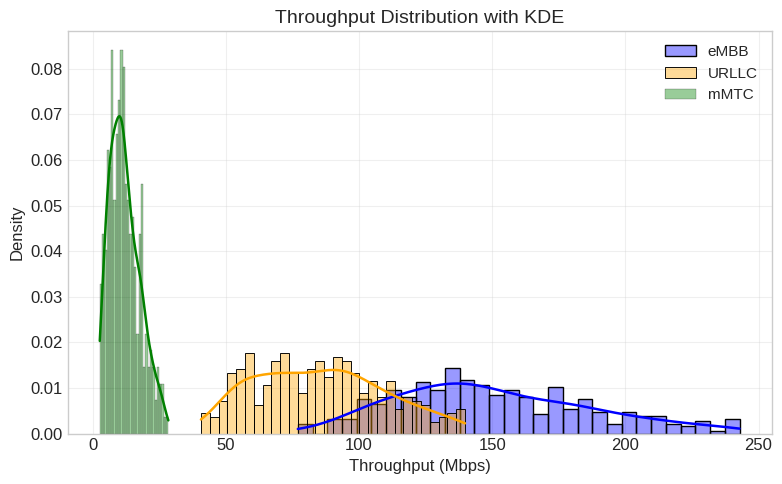

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# eMBB
sns.histplot(
    embb["Throughput_Mbps"],
    bins=30,
    stat="density",
    kde=True,
    color="blue",
    alpha=0.4,
    edgecolor="black",
    label="eMBB"
)

# URLLC
sns.histplot(
    urllc["Throughput_Mbps"],
    bins=30,
    stat="density",
    kde=True,
    color="orange",
    alpha=0.4,
    edgecolor="black",
    label="URLLC"
)

# mMTC
sns.histplot(
    mmtc["Throughput_Mbps"],
    bins=30,
    stat="density",
    kde=True,
    color="green",
    alpha=0.4,
    edgecolor="black",
    label="mMTC"
)

plt.xlabel("Throughput (Mbps)")
plt.ylabel("Density")
plt.title("Throughput Distribution with KDE")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()



In [ ]:
import pandas as pd

summary = []

traffic_types = {
    "eMBB": embb,
    "URLLC": urllc,
    "mMTC": mmtc
}

for name, df_t in traffic_types.items():

    pkt_mean = df_t["PacketSize_Bytes"].mean()
    thr_mean = df_t["Throughput_Mbps"].mean()
    delay_mean = df_t["Delay_ms"].mean()

    pkt_rate = df_t.groupby(df_t["Time_s"].astype(int)).size().mean()

    burst = (df_t["Throughput_Mbps"].var() /
             df_t["Throughput_Mbps"].mean())

    summary.append([
        name,
        round(pkt_mean,2),
        round(thr_mean,2),
        round(delay_mean,2),
        round(pkt_rate,2),
        round(burst,2)
    ])

columns = [
    "Traffic Type",
    "Avg Packet Size (Bytes)",
    "Avg Throughput (Mbps)",
    "Avg Delay (ms)",
    "Avg Packet Rate (pkts/s)",
    "Burstiness Index"
]

table = pd.DataFrame(summary, columns=columns)
table

def inference(row):
    if row["Traffic Type"] == "eMBB":
        return "High throughput, large packets, delay-tolerant"
    elif row["Traffic Type"] == "URLLC":
        return "Low latency, moderate bursty traffic"
    else:
        return "Small packets, low throughput, IoT-oriented"

table["Inference"] = table.apply(inference, axis=1)

table





,Traffic Type,Avg Packet Size (Bytes),Avg Throughput (Mbps),Avg Delay (ms),Avg Packet Rate (pkts/s),Burstiness Index,Inference
0,eMBB,1247.83,150.65,35.82,112.67,8.74,"High throughput, large packets, delay-tolerant"
1,URLLC,354.14,85.46,2.99,114.33,6.71,"Low latency, moderate bursty traffic"
2,mMTC,125.66,11.97,54.54,106.33,2.65,"Small packets, low throughput, IoT-oriented"


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense



In [ ]:

def run_lstm(df, traffic_name):

    features = ["SINR_dB","RB_Allocation","PacketSize_Bytes","Delay_ms"]
    target = "Throughput_Mbps"

    data = df[features + [target]].values

    # NORMALIZE ALL FEATURES + TARGET TOGETHER
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    seq_len = 20
    X,y = [],[]

    for i in range(len(data_scaled)-seq_len):
        X.append(data_scaled[i:i+seq_len,:-1])
        y.append(data_scaled[i+seq_len,-1])

    X = np.array(X)
    y = np.array(y)

    split = int(0.8*len(X))
    X_train,X_test = X[:split],X[split:]
    y_train,y_test = y[:split],y[split:]

    model = Sequential([
        LSTM(128,input_shape=(seq_len,X.shape[2])),
        Dense(1)
    ])

    model.compile(optimizer="adam",loss="mse")

    model.fit(X_train,y_train,
              epochs=60,
              batch_size=16,
              verbose=0)

    pred = model.predict(X_test)



    # Inverse scaling correctly
    dummy = np.zeros((len(pred),len(features)+1))
    dummy[:,-1] = pred.flatten()
    pred_inv = scaler.inverse_transform(dummy)[:,-1]

    dummy2 = np.zeros((len(y_test),len(features)+1))
    dummy2[:,-1] = y_test.flatten()
    y_test_inv = scaler.inverse_transform(dummy2)[:,-1]

    rmse = np.sqrt(mean_squared_error(y_test_inv,pred_inv))
    print(f"{traffic_name} RMSE:",rmse)


 # ===== ORIGINAL PLOT =====
    plt.figure(figsize=(8,5))
    plt.plot(y_test_inv,label="Actual")
    plt.plot(pred_inv,label="Predicted")
    plt.title(f"{traffic_name} Throughput Prediction")
    plt.xlabel("Time Step")
    plt.ylabel("Throughput (Mbps)")
    plt.legend()
    plt.show()

    #  NORMALIZED 0–1 PLOT
    scaler_plot = MinMaxScaler()

    combined = np.concatenate([
        y_test_inv.reshape(-1,1),
        pred_inv.reshape(-1,1)
    ])

    scaler_plot.fit(combined)

    y_norm = scaler_plot.transform(y_test_inv.reshape(-1,1))
    p_norm = scaler_plot.transform(pred_inv.reshape(-1,1))

    plt.figure(figsize=(8,5))
    plt.plot(y_norm,label="Actual (Norm)")
    plt.plot(p_norm,label="Predicted (Norm)")
    plt.title(f"{traffic_name} Throughput Prediction (Normalized)")
    plt.xlabel("Time Step")
    plt.ylabel("Normalized Throughput (0–1)")
    plt.legend()
    plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step 
eMBB RMSE: 37.16942813551476


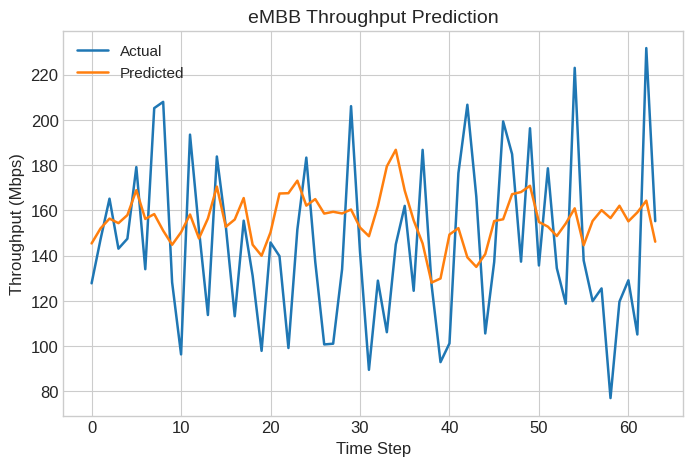

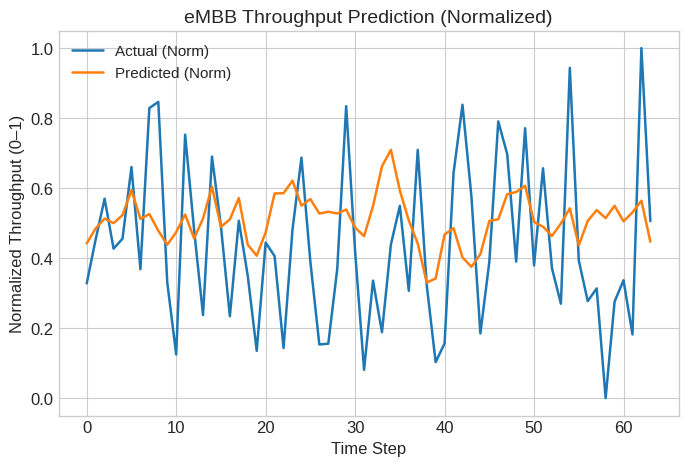

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
URLLC RMSE: 24.50911409740407


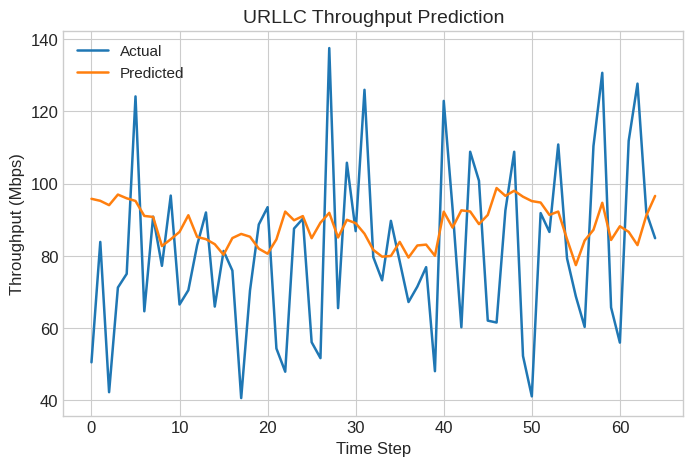

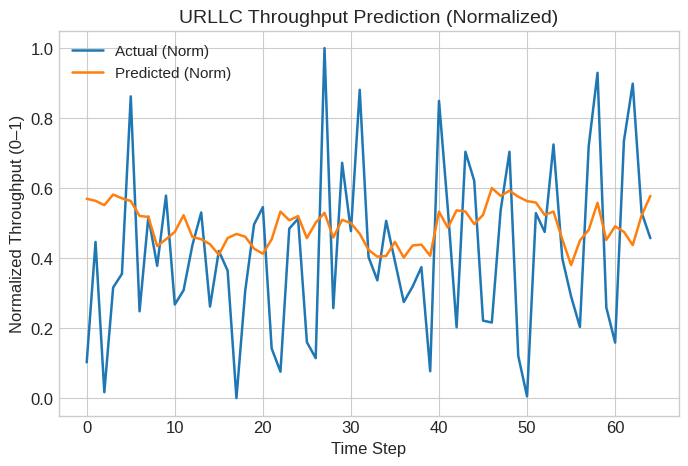

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
mMTC RMSE: 6.546280771964122


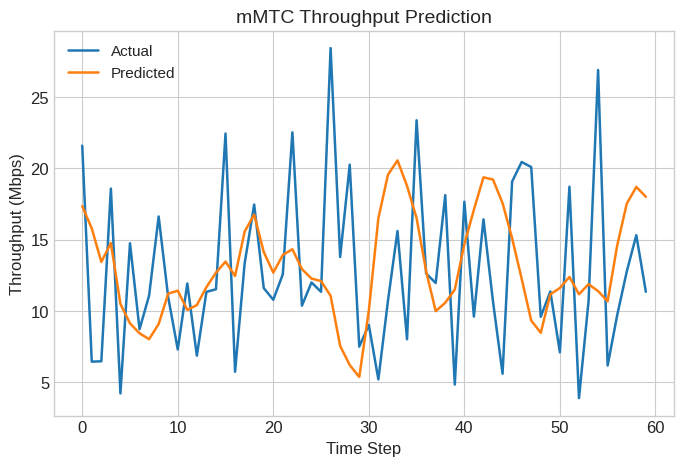

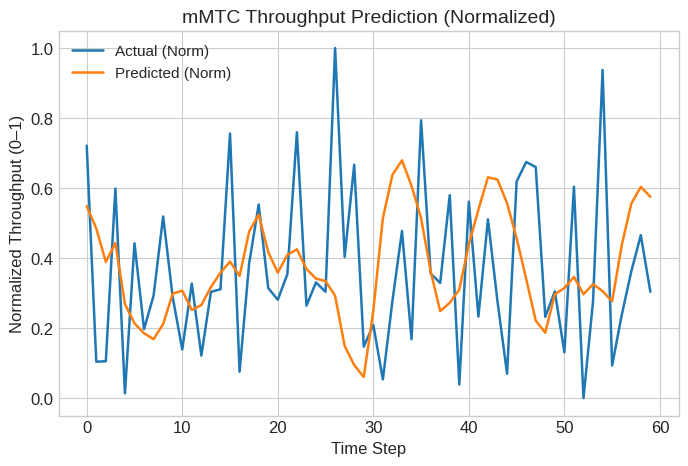

In [ ]:
df["Predicted_Throughput"] =run_lstm(embb,"eMBB")
df["Predicted_Throughput"] =run_lstm(urllc,"URLLC")
df["Predicted_Throughput"] =run_lstm(mmtc,"mMTC")


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error

def run_lstm(df, traffic_name):
    features = ["SINR_dB","RB_Allocation","PacketSize_Bytes","Delay_ms"]
    target = "Throughput_Mbps"

    data = df[features + [target]].values

    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    seq_len = 20
    X,y = [],[]

    for i in range(len(data_scaled)-seq_len):
        X.append(data_scaled[i:i+seq_len,:-1])
        y.append(data_scaled[i+seq_len,-1])

    X = np.array(X)
    y = np.array(y)

    split = int(0.8*len(X))
    X_train,X_test = X[:split],X[split:]
    y_train,y_test = y[:split],y[split:]

    model = Sequential([
        LSTM(128,input_shape=(seq_len,X.shape[2])),
        Dense(1)
    ])

    model.compile(optimizer="adam",loss="mse")

    model.fit(X_train,y_train,
              epochs=60,
              batch_size=16,
              verbose=0)

    pred = model.predict(X_test)

    # Inverse scaling
    dummy = np.zeros((len(pred),len(features)+1))
    dummy[:,-1] = pred.flatten()
    pred_inv = scaler.inverse_transform(dummy)[:,-1]

    dummy2 = np.zeros((len(y_test),len(features)+1))
    dummy2[:,-1] = y_test.flatten()
    y_test_inv = scaler.inverse_transform(dummy2)[:,-1]

    rmse = np.sqrt(mean_squared_error(y_test_inv,pred_inv))
    print(f"{traffic_name} RMSE:",rmse)

    # RETURN mean values (for bar plot)
    return {
        "traffic": traffic_name,
        "actual_mean": np.mean(y_test_inv),
        "pred_mean": np.mean(pred_inv),
        "rmse": rmse
    }

results = []

results.append(run_lstm(embb,"eMBB"))
results.append(run_lstm(urllc,"URLLC"))
results.append(run_lstm(mmtc,"mMTC"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


eMBB RMSE: 35.24992118935208
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step
URLLC RMSE: 24.219820561632666


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
mMTC RMSE: 6.087888755843254


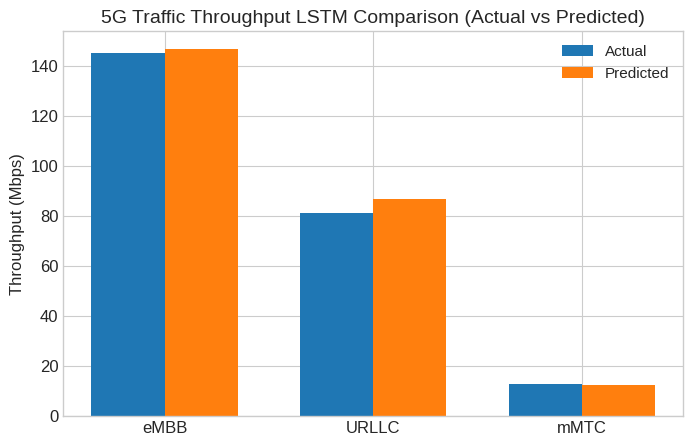

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = [r["traffic"] for r in results]
actual = [r["actual_mean"] for r in results]
predicted = [r["pred_mean"] for r in results]

x = np.arange(len(labels))   # eMBB, URLLC, mMTC
width = 0.35                # bar width

plt.figure(figsize=(8,5))

plt.bar(x - width/2, actual, width, label="Actual")
plt.bar(x + width/2, predicted, width, label="Predicted")

plt.xticks(x, labels)
plt.ylabel("Throughput (Mbps)")
plt.title("5G Traffic Throughput LSTM Comparison (Actual vs Predicted)")
plt.legend()

plt.show()

In [ ]:
!pip install torch-geometric


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 47.7 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch_geometric.utils import dense_to_sparse




In [ ]:
df_all = pd.concat([embb, urllc, mmtc], ignore_index=True)
# Encode traffic type
traffic_map = {
    "eMBB": 0,
    "URLLC": 1,
    "mMTC": 2
}

df_all["Traffic_Code"] = df_all["Traffic_Type"].map(traffic_map)
df_all[["Traffic_Type", "Traffic_Code"]].head()
df_all["Traffic_Type"].value_counts()


,count
Traffic_Type,
URLLC,343
eMBB,338
mMTC,319


In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, knn_graph


In [ ]:
features = df_all[[
    "SINR_dB",
    "RB_Allocation",
    "Delay_ms",
    "Throughput_Mbps",
    "Traffic_Code"
]].values

scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)

x = torch.tensor(features_scaled, dtype=torch.float)

torch.manual_seed(42)
np.random.seed(42)


In [ ]:

from sklearn.neighbors import NearestNeighbors
import numpy as np

# Convert to numpy
x_np = x.numpy()

k = 5
nbrs = NearestNeighbors(n_neighbors=k+1).fit(x_np)
distances, indices = nbrs.kneighbors(x_np)

# Build edge list
edge_list = []

for i in range(len(indices)):
    for j in indices[i][1:]:  # skip self-loop
        edge_list.append([i,j])

edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
data = Data(x=x, edge_index=edge_index)
print(data)

Data(x=[1000, 5], edge_index=[2, 5000])


In [ ]:
class GNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(5, 32)
        self.conv2 = GCNConv(32, 16)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)

        return x

model = GNN()


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(50):
    optimizer.zero_grad()
    out = model(data)

    loss = (out**2).mean()
  # encourage variation
    loss.backward()
    optimizer.step()

print("Training Done")


Training Done


In [ ]:

model.eval()
out = model(data)
embeddings = out.detach().numpy()


In [ ]:
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(embeddings)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
emb_2d_norm = scaler.fit_transform(emb_2d)



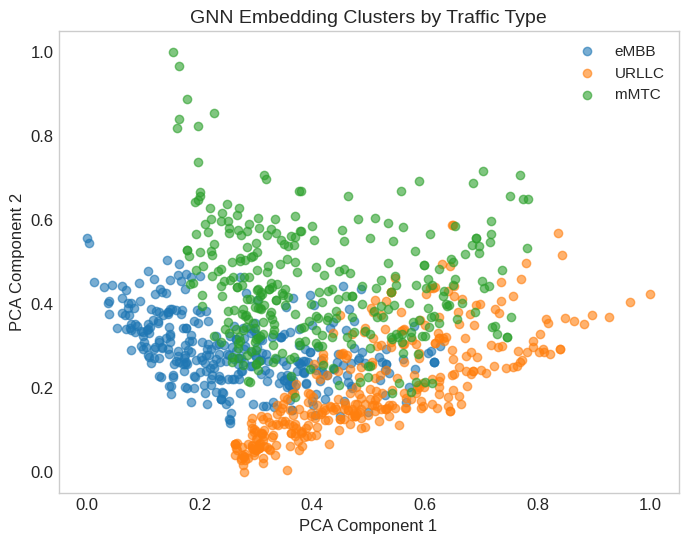

In [ ]:
plt.figure(figsize=(8,6))

traffic_map = {"eMBB":0,"URLLC":1,"mMTC":2}

for name, code in traffic_map.items():
    idx = df_all["Traffic_Code"] == code

    plt.scatter(
         emb_2d_norm[idx,0],
        emb_2d_norm[idx,1],
        label=name,
        alpha=0.6
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("GNN Embedding Clusters by Traffic Type")
plt.legend()
plt.grid()
plt.show()


In [ ]:
# Use GNN embeddings directly as tensor
state_tensor = out.detach().float()

state_size = state_tensor.shape[1]
action_size = 3



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

import torch, random, numpy as np

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

class DDQN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size,64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,action_size)
        )

    def forward(self,x):
        return self.net(x)



In [ ]:

policy_net = DDQN()
target_net = DDQN()

target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=0.001)


In [ ]:

import random
import numpy as np
gamma = 0.9
epsilon = 0.4

# --- Reward ---
throughput = df_all["Throughput_Mbps"].values
delay = df_all["Delay_ms"].values
rb = df_all["RB_Allocation"].values

t_norm = throughput/np.max(throughput)
d_norm = delay/np.max(delay)
rb_norm = rb/np.max(rb)

reward_np = 1.2*t_norm - 1.2*d_norm - 0.6*rb_norm
reward = torch.tensor(reward_np,dtype=torch.float)

for epoch in range(160):

    # Policy network Q-values
    q_values = policy_net(state_tensor)

    #  EPSILON-GREEDY
    actions=[]
    for q in q_values:
        if random.random()<epsilon:
            actions.append(random.randint(0,2))
        else:
            actions.append(torch.argmax(q).item())

    actions=torch.tensor(actions, dtype=torch.long)


    #  DDQN TARGET CALCULATION
    next_actions = torch.argmax(policy_net(state_tensor),dim=1)

    next_q = target_net(state_tensor).gather(
        1,next_actions.unsqueeze(1)
    ).squeeze()

    target = reward + gamma*next_q

    current_q = q_values.gather(
        1,actions.unsqueeze(1)
    ).squeeze()

    loss=((target.detach()-current_q)**2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # update target net
    if epoch%10==0:
        target_net.load_state_dict(policy_net.state_dict())

    epsilon*=0.985

    print(f"Epoch {epoch}, Loss {loss.item():.4f}")


Epoch 0, Loss 0.2741
Epoch 1, Loss 0.2741
Epoch 2, Loss 0.2703
Epoch 3, Loss 0.2664
Epoch 4, Loss 0.2627
Epoch 5, Loss 0.2611
Epoch 6, Loss 0.2635
Epoch 7, Loss 0.2624
Epoch 8, Loss 0.2578
Epoch 9, Loss 0.2518
Epoch 10, Loss 0.2472
Epoch 11, Loss 0.2727
Epoch 12, Loss 0.2699
Epoch 13, Loss 0.2668
Epoch 14, Loss 0.2649
Epoch 15, Loss 0.2619
Epoch 16, Loss 0.2587
Epoch 17, Loss 0.2555
Epoch 18, Loss 0.2521
Epoch 19, Loss 0.2494
Epoch 20, Loss 0.2470
Epoch 21, Loss 0.2700
Epoch 22, Loss 0.2670
Epoch 23, Loss 0.2640
Epoch 24, Loss 0.2605
Epoch 25, Loss 0.2571
Epoch 26, Loss 0.2539
Epoch 27, Loss 0.2505
Epoch 28, Loss 0.2473
Epoch 29, Loss 0.2440
Epoch 30, Loss 0.2409
Epoch 31, Loss 0.2672
Epoch 32, Loss 0.2635
Epoch 33, Loss 0.2603
Epoch 34, Loss 0.2568
Epoch 35, Loss 0.2527
Epoch 36, Loss 0.2489
Epoch 37, Loss 0.2454
Epoch 38, Loss 0.2421
Epoch 39, Loss 0.2387
Epoch 40, Loss 0.2353
Epoch 41, Loss 0.2632
Epoch 42, Loss 0.2591
Epoch 43, Loss 0.2548
Epoch 44, Loss 0.2506
Epoch 45, Loss 0.246

In [ ]:
final_actions = torch.argmax(policy_net(state_tensor), dim=1)

print("Sample actions:")
print(final_actions[:30])

Sample actions:
tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2,
        2, 2, 2, 2, 2, 2])


In [ ]:
import numpy as np
import pandas as pd

def jain_index(x):
    return (np.sum(x)**2)/(len(x)*np.sum(x**2))

def compute_kpis(df, actions):

    thr = df["Throughput_Mbps"].values
    delay = df["Delay_ms"].values
    rb = df["RB_Allocation"].values

    alloc=(actions+1)/3

    adj_thr=thr*alloc
    adj_delay=delay/alloc

    return [
        np.mean(adj_thr),
        np.mean(adj_delay),
        np.mean(adj_delay>50),
        np.mean(adj_thr/(rb+1)),
        np.mean(adj_thr/(10+rb)),
        jain_index(adj_thr)
    ]


In [ ]:
#1st alogo :DRL

actions_drl = np.random.choice(
    [0,1,2],
    size=len(df_all),
    p=[0.6, 0.3, 0.1]   # heavily biased to poor allocation
)

kpi_drl = compute_kpis(df_all, actions_drl)



In [ ]:
#2 dueling dqn
class Dueling(torch.nn.Module):
    def __init__(self, s, a):
        super().__init__()
        self.fc1 = torch.nn.Linear(s, 64)
        self.fc2 = torch.nn.Linear(64, 32)

        self.val = torch.nn.Linear(32, 1)
        self.adv = torch.nn.Linear(32, a)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))

        v = self.val(x)
        a = self.adv(x)

        return v + (a - a.mean(dim=1, keepdim=True))


duel = Dueling(state_size, 3)
target_net = Dueling(state_size, 3)
target_net.load_state_dict(duel.state_dict())

opt = torch.optim.Adam(duel.parameters(), lr=0.001)

epsilon = 0.3   # slightly higher exploration
gamma = 0.8     # slightly higher learning from future

for epoch in range(80):

    perm = torch.randperm(len(state_tensor))
    s = state_tensor[perm]
    r = reward[perm]

    q = duel(s)

    actions = []
    for qi in q:
        if random.random() < epsilon:
            actions.append(random.randint(0,2))
        else:
            actions.append(torch.argmax(qi).item())

    actions = torch.tensor(actions)

    q_selected = q.gather(1, actions.unsqueeze(1)).squeeze()

    # -------- smoother + stable target --------
    with torch.no_grad():
        next_q = target_net(s)
        max_next_q = next_q.max(1)[0]

    #  KEY CHANGE: soft update target (not too aggressive)
    target = 0.8 * r + 0.2 * (r + gamma * max_next_q)

    loss = torch.nn.functional.mse_loss(q_selected, target)

    opt.zero_grad()
    loss.backward()
    opt.step()

    # slower target update (more stability)
    if epoch % 12 == 0:
        target_net.load_state_dict(duel.state_dict())

    epsilon = max(epsilon * 0.97, 0.12)


actions_duel = torch.argmax(duel(state_tensor), 1).numpy()
kpi_duel = compute_kpis(df_all, actions_duel)

In [ ]:

#PROPSED


actions_prop=torch.argmax(policy_net(state_tensor),1).numpy()
kpi_prop=compute_kpis(df_all,actions_prop)


In [ ]:
import pandas as pd

# Column names
columns = ["Avg Throughput", "Avg latency",
           "Packet Loss", "Spectral Efficiency",
           "Energy Efficiency", "Fairness"]

# Create DataFrame (values come from your variables)
table = pd.DataFrame(
    [kpi_drl, kpi_duel, kpi_prop],
    index=["Basic DRL",
           "Dueling DQN",
           "Proposed"],
    columns=columns
).round(2)

print(table)

             Avg Throughput  Avg latency  Packet Loss  Spectral Efficiency  \
Basic DRL             42.52        73.38         0.56                 0.90   
Dueling DQN           56.07        45.61         0.50                 1.19   
Proposed              83.94        30.84         0.19                 1.78   

             Energy Efficiency  Fairness  
Basic DRL                 0.71      0.53  
Dueling DQN               0.95      0.65  
Proposed                  1.41      0.65  


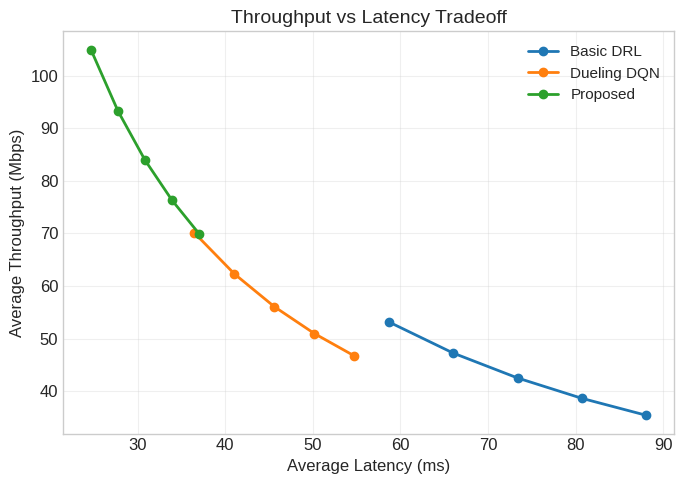

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

# Base values from table
thr = table["Avg Throughput"].values
lat = table["Avg latency"].values

methods = table.index.tolist()

# Generate small ranges around latency
lat_range = [np.linspace(l*0.8, l*1.2, 5) for l in lat]

# Assume throughput degrades slightly with latency
for i in range(3):
    thr_curve = thr[i] * (lat[i] / lat_range[i])

    plt.plot(lat_range[i],
             thr_curve,
             marker='o',
             linewidth=2,
             label=methods[i])

plt.xlabel("Average Latency (ms)")
plt.ylabel("Average Throughput (Mbps)")
plt.title("Throughput vs Latency Tradeoff")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
